In [1]:
import sys
print(sys.executable)


C:\Users\Admin\OneDrive\Documents\AI-Net\venv\Scripts\python.exe


In [2]:
import pandas as pd

file_path = "../data/raw/MachineLearningCSV/MachineLearningCVE/Monday-WorkingHours.pcap_ISCX.csv"

df = pd.read_csv(file_path, nrows=5000)

print(df.shape)

(5000, 79)


In [3]:
print(df.columns.tolist())

[' Destination Port', ' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets', 'Total Length of Fwd Packets', ' Total Length of Bwd Packets', ' Fwd Packet Length Max', ' Fwd Packet Length Min', ' Fwd Packet Length Mean', ' Fwd Packet Length Std', 'Bwd Packet Length Max', ' Bwd Packet Length Min', ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max', ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std', ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length', ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s', ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean', ' Packet Length Std', ' Packet Length Variance', 'FIN Flag Count', ' SYN Flag Count', ' RST Flag Count', ' PSH Flag Count', ' ACK Flag Count', ' URG Flag 

In [4]:
df["Label"].value_counts()

KeyError: 'Label'

In [5]:
df.columns = df.columns.str.strip()

print(df["Label"].value_counts())

Label
BENIGN    5000
Name: count, dtype: int64


In [6]:
df.columns = df.columns.str.strip()

print(df["Label"].value_counts())

Label
BENIGN    5000
Name: count, dtype: int64


In [7]:
file_path = "../data/raw/MachineLearningCSV/MachineLearningCVE/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv"

df_ddos = pd.read_csv(file_path, nrows=5000)

df_ddos.columns = df_ddos.columns.str.strip()

print(df_ddos.shape)
print(df_ddos["Label"].value_counts())

(5000, 79)
Label
BENIGN    5000
Name: count, dtype: int64


In [8]:
df_ddos = pd.read_csv(file_path)

df_ddos.columns = df_ddos.columns.str.strip()

df_ddos_sample = df_ddos.sample(n=5000, random_state=42)

print(df_ddos_sample.shape)
print(df_ddos_sample["Label"].value_counts())

(5000, 79)
Label
DDoS      2875
BENIGN    2125
Name: count, dtype: int64


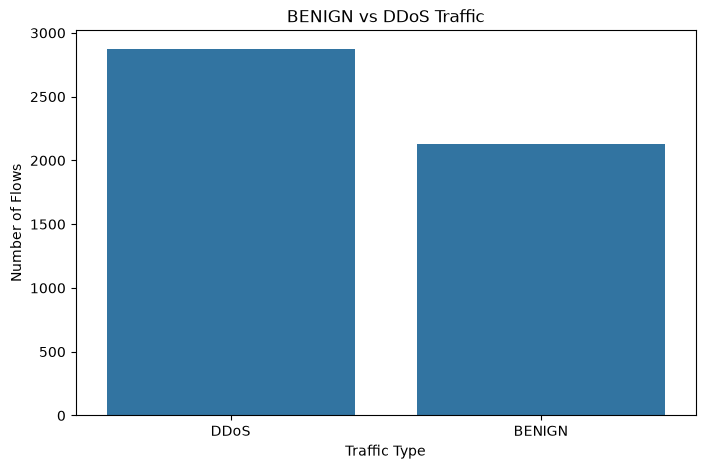

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_ddos_sample,
    x="Label"
)

plt.title("BENIGN vs DDoS Traffic")
plt.xlabel("Traffic Type")
plt.ylabel("Number of Flows")

plt.show()

In [10]:
# Check missing values
missing_values = df_ddos_sample.isnull().sum()

print(missing_values[missing_values > 0])

Series([], dtype: int64)


In [11]:
# Check duplicate rows
print("Duplicate rows:", df_ddos_sample.duplicated().sum())

Duplicate rows: 4


In [12]:
print(df_ddos_sample.dtypes)


Destination Port                 int64
Flow Duration                    int64
Total Fwd Packets                int64
Total Backward Packets           int64
Total Length of Fwd Packets      int64
                                ...   
Idle Mean                      float64
Idle Std                       float64
Idle Max                         int64
Idle Min                         int64
Label                              str
Length: 79, dtype: object


In [13]:
df_ddos_sample.describe()

C:\Users\Admin\OneDrive\Documents\AI-Net\venv\Lib\site-packages\pandas\core\nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
C:\Users\Admin\OneDrive\Documents\AI-Net\venv\Lib\site-packages\pandas\core\nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,5000.000000,5.000000e+03,5000.000000,5000.000000,5000.000000,5.000000e+03,5000.00000,5000.000000,5000.000000,5000.000000,...,5000.000000,5000.000000,5.000000e+03,5.000000e+03,5.000000e+03,5.000000e+03,5.000000e+03,5.000000e+03,5.000000e+03,5.000000e+03
mean,8709.887200,1.572856e+07,4.719800,4.370200,906.404200,5.673627e+03,525.62700,25.375800,160.683650,212.092710,...,3.213800,21.499200,2.012236e+05,1.042579e+04,2.199268e+05,1.960212e+05,1.018178e+07,3.364748e+06,1.255984e+07,7.792175e+06
std,19660.581051,3.078973e+07,15.517353,18.893325,3020.252321,3.302537e+04,1832.94159,152.724756,498.251177,788.489864,...,8.387524,4.158733,7.950527e+05,1.341616e+05,8.459690e+05,7.912859e+05,2.175224e+07,1.239008e+07,2.657265e+07,1.984269e+07
min,21.000000,0.000000e+00,1.000000,0.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,...,0.000000,20.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,80.000000,7.271725e+04,2.000000,1.000000,26.000000,0.000000e+00,6.00000,0.000000,6.000000,0.000000,...,1.000000,20.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,80.000000,1.369403e+06,3.000000,4.000000,30.000000,1.640000e+02,20.00000,0.000000,8.666667,5.301991,...,2.000000,20.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,80.000000,8.556924e+06,5.000000,5.000000,62.000000,1.160100e+04,34.00000,6.000000,33.000000,10.263203,...,4.000000,20.000000,1.331500e+03,0.000000e+00,1.331500e+03,1.281250e+03,8.116022e+06,0.000000e+00,8.116022e+06,7.354301e+06
max,65517.000000,1.196336e+08,1035.000000,1242.000000,59368.000000,2.202548e+06,11595.00000,1375.000000,3244.000000,5796.500690,...,506.000000,40.000000,8.770076e+06,4.175980e+06,1.030000e+07,8.770076e+06,1.180000e+08,6.340000e+07,1.180000e+08,1.180000e+08


In [14]:
import numpy as np

print("Infinite values:", np.isinf(df_ddos_sample.select_dtypes(include=np.number)).sum().sum())

Infinite values: 2


In [15]:
# Find columns containing infinite values
numeric_cols = df_ddos_sample.select_dtypes(include=np.number).columns

inf_counts = np.isinf(df_ddos_sample[numeric_cols]).sum()

print(inf_counts[inf_counts > 0])

Flow Bytes/s      1
Flow Packets/s    1
dtype: int64


In [16]:
# Replace infinite values with NaN
df_ddos_sample = df_ddos_sample.replace([np.inf, -np.inf], np.nan)

# Check again
print("Infinite values:",
      np.isinf(df_ddos_sample.select_dtypes(include=np.number)).sum().sum())

print("\nMissing values after replacement:")
print(df_ddos_sample.isnull().sum()[df_ddos_sample.isnull().sum() > 0])

Infinite values: 0

Missing values after replacement:
Flow Bytes/s      1
Flow Packets/s    1
dtype: int64


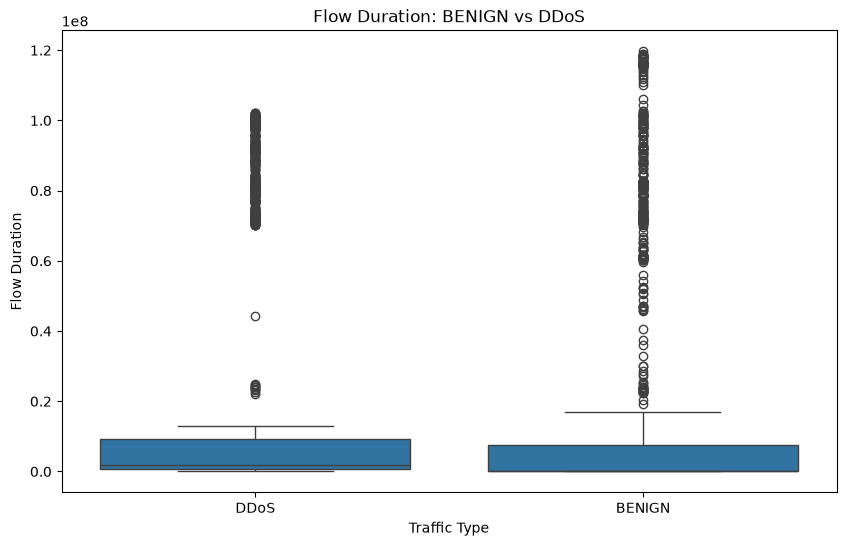

In [17]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_ddos_sample,
    x="Label",
    y="Flow Duration"
)

plt.title("Flow Duration: BENIGN vs DDoS")
plt.xlabel("Traffic Type")
plt.ylabel("Flow Duration")
plt.show()

In [18]:
print("DAY 1 OBSERVATIONS")
print("-------------------")

print("1. Dataset contains 79 columns.")
print("2. 78 columns are numerical network traffic features.")
print("3. Label is the target variable.")
print("4. Sample contains BENIGN and DDoS traffic.")
print("5. 4 duplicate rows were found in the 5,000-row sample.")
print("6. 2 infinite values were found in Flow Bytes/s and Flow Packets/s.")
print("7. Infinite values were replaced with NaN.")
print("8. Flow Duration shows significant variation and outliers.")
print("9. Multiple network features will be required for reliable attack detection.")

DAY 1 OBSERVATIONS
-------------------
1. Dataset contains 79 columns.
2. 78 columns are numerical network traffic features.
3. Label is the target variable.
4. Sample contains BENIGN and DDoS traffic.
5. 4 duplicate rows were found in the 5,000-row sample.
6. 2 infinite values were found in Flow Bytes/s and Flow Packets/s.
7. Infinite values were replaced with NaN.
8. Flow Duration shows significant variation and outliers.
9. Multiple network features will be required for reliable attack detection.


In [19]:
import pandas as pd
import numpy as np

In [20]:
print("Day 2 - Data Preprocessing Started")

Day 2 - Data Preprocessing Started


In [21]:
df = pd.read_csv("../data/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv")

FileNotFoundError: [Errno 2] No such file or directory: '../data/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv'

In [22]:
print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (5000, 79)


In [23]:
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 79 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Destination Port             5000 non-null   int64  
 1   Flow Duration                5000 non-null   int64  
 2   Total Fwd Packets            5000 non-null   int64  
 3   Total Backward Packets       5000 non-null   int64  
 4   Total Length of Fwd Packets  5000 non-null   int64  
 5   Total Length of Bwd Packets  5000 non-null   int64  
 6   Fwd Packet Length Max        5000 non-null   int64  
 7   Fwd Packet Length Min        5000 non-null   int64  
 8   Fwd Packet Length Mean       5000 non-null   float64
 9   Fwd Packet Length Std        5000 non-null   float64
 10  Bwd Packet Length Max        5000 non-null   int64  
 11  Bwd Packet Length Min        5000 non-null   int64  
 12  Bwd Packet Length Mean       5000 non-null   float64
 13  Bwd Pack

In [24]:
print("Column Names:")
print(df.columns.tolist())

Column Names:
['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', '

In [25]:
print("Missing values in each column:")
print(df.isnull().sum().sum())

Missing values in each column:
1


In [26]:
missing = df.isnull().sum()

print("Columns containing missing values:")
print(missing[missing > 0])

Columns containing missing values:
Flow Bytes/s    1
dtype: int64


In [27]:
print("\nRow containing the missing value:")
print(df[df.isnull().any(axis=1)])


Row containing the missing value:
      Destination Port  Flow Duration  Total Fwd Packets  \
3986               443              0                  1   

      Total Backward Packets  Total Length of Fwd Packets  \
3986                       1                            0   

      Total Length of Bwd Packets  Fwd Packet Length Max  \
3986                            0                      0   

      Fwd Packet Length Min  Fwd Packet Length Mean  Fwd Packet Length Std  \
3986                      0                     0.0                    0.0   

      ...  min_seg_size_forward  Active Mean  Active Std  Active Max  \
3986  ...                    32          0.0         0.0           0   

      Active Min  Idle Mean  Idle Std  Idle Max  Idle Min   Label  
3986           0        0.0       0.0         0         0  BENIGN  

[1 rows x 79 columns]


In [28]:
df["Flow Bytes/s"] = df["Flow Bytes/s"].fillna(0)

print("Missing values after cleaning:")
print(df.isnull().sum().sum())

Missing values after cleaning:
0


In [29]:
.fillna(0)

SyntaxError: invalid syntax (2147338155.py, line 1)

In [30]:
print("Positive Infinity values:")
print(np.isposinf(df.select_dtypes(include=np.number)).sum().sum())

print("Negative Infinity values:")
print(np.isneginf(df.select_dtypes(include=np.number)).sum().sum())

Positive Infinity values:
27
Negative Infinity values:
0


In [31]:
inf_counts = np.isinf(df.select_dtypes(include=np.number)).sum()

print("Columns containing infinity values:")
print(inf_counts[inf_counts > 0])

Columns containing infinity values:
Flow Bytes/s      13
Flow Packets/s    14
dtype: int64


In [32]:
# Replace positive and negative infinity with 0
df.replace([np.inf, -np.inf], 0, inplace=True)

print("Infinity values after cleaning:")
print(np.isinf(df.select_dtypes(include=np.number)).sum().sum())

Infinity values after cleaning:
0


In [33]:
print("Duplicate rows:")
print(df.duplicated().sum())

Duplicate rows:
86


In [34]:
duplicate_count = df.duplicated().sum()
duplicate_percentage = (duplicate_count / len(df)) * 100

print("Duplicate percentage:", duplicate_percentage, "%")

Duplicate percentage: 1.72 %


In [35]:
before = len(df)

df = df.drop_duplicates()

after = len(df)

print("Rows before removing duplicates:", before)
print("Rows after removing duplicates:", after)
print("Duplicates removed:", before - after)

Rows before removing duplicates: 5000
Rows after removing duplicates: 4914
Duplicates removed: 86


In [36]:
print("Remaining duplicate rows:", df.duplicated().sum())

Remaining duplicate rows: 0


In [37]:
# Remove leading and trailing spaces from column names
df.columns = df.columns.str.strip()

print("Column names cleaned successfully.")
print(df.columns.tolist())

Column names cleaned successfully.
['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count'

In [38]:
print("\nTarget column:")
print("Label" in df.columns)


Target column:
True


In [39]:
df["Label"]

0       BENIGN
1       BENIGN
4       BENIGN
5       BENIGN
8       BENIGN
         ...  
4995    BENIGN
4996    BENIGN
4997    BENIGN
4998    BENIGN
4999    BENIGN
Name: Label, Length: 4914, dtype: str

In [40]:
df.columns = df.columns.str.strip()

In [41]:
# Separate features and target

X = df.drop("Label", axis=1)
y = df["Label"]

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

Features (X) shape: (4914, 78)
Target (y) shape: (4914,)


In [42]:
X = df.drop("Label", axis=1)

In [43]:
y = df["Label"]

In [44]:
print("\nTarget classes:")
print(y.value_counts())


Target classes:
Label
BENIGN    4914
Name: count, dtype: int64


In [45]:
print("Unique labels:")
print(df["Label"].unique())

print("\nNumber of unique labels:")
print(df["Label"].nunique())

Unique labels:
<StringArray>
['BENIGN']
Length: 1, dtype: str

Number of unique labels:
1


In [46]:
print("\nLabel distribution:")
print(df["Label"].value_counts(dropna=False))


Label distribution:
Label
BENIGN    4914
Name: count, dtype: int64


In [47]:
import os

data_folder = "../data"

print("Files in data folder:")
for file in os.listdir(data_folder):
    print(file)

Files in data folder:
raw


In [48]:
import glob

csv_files = glob.glob("../data/*.csv")

print("\nCSV files found:")
for file in csv_files:
    print(file)


CSV files found:


In [49]:
import os
import glob

raw_folder = "../data/raw"

print("Files in raw folder:")
for file in os.listdir(raw_folder):
    print(file)

Files in raw folder:
MachineLearningCSV
MachineLearningCSV.zip


In [50]:
csv_files = glob.glob("../data/raw/*.csv")

print("\nCSV files found:")
for file in csv_files:
    print(file)


CSV files found:


In [51]:
import zipfile

zip_path = "../data/raw/MachineLearningCSV.zip"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    files = zip_ref.namelist()

print("Files inside ZIP:")
for file in files:
    print(file)

Files inside ZIP:
MachineLearningCVE/
MachineLearningCVE/Wednesday-workingHours.pcap_ISCX.csv
MachineLearningCVE/Tuesday-WorkingHours.pcap_ISCX.csv
MachineLearningCVE/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
MachineLearningCVE/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
MachineLearningCVE/Monday-WorkingHours.pcap_ISCX.csv
MachineLearningCVE/Friday-WorkingHours-Morning.pcap_ISCX.csv
MachineLearningCVE/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
MachineLearningCVE/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv


In [52]:
import os

dataset_folder = "../data/raw/MachineLearningCSV"

print("Files in MachineLearningCSV folder:")
for file in os.listdir(dataset_folder):
    print(file)

Files in MachineLearningCSV folder:
MachineLearningCVE


In [53]:
dataset_folder = "../data/raw/MachineLearningCSV/MachineLearningCVE"

print("Files in final dataset folder:")
for file in os.listdir(dataset_folder):
    print(file)

Files in final dataset folder:
Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Friday-WorkingHours-Morning.pcap_ISCX.csv
Monday-WorkingHours.pcap_ISCX.csv
Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Tuesday-WorkingHours.pcap_ISCX.csv
Wednesday-workingHours.pcap_ISCX.csv


In [54]:
ddos_path = "../data/raw/MachineLearningCSV/MachineLearningCVE/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv"

df = pd.read_csv(ddos_path)

print("DDoS dataset loaded successfully!")
print("Shape:", df.shape)

DDoS dataset loaded successfully!
Shape: (225745, 79)


In [55]:
print("\nLabel distribution:")
print(df["Label"].value_counts())


Label distribution:


KeyError: 'Label'

In [56]:
# Clean column names
df.columns = df.columns.str.strip()

print("Last 5 column names:")
print(df.columns[-5:].tolist())

Last 5 column names:
['Idle Mean', 'Idle Std', 'Idle Max', 'Idle Min', 'Label']


In [57]:
print("Does Label exist?")
print("Label" in df.columns)

print("\nColumns containing 'Label':")
print([col for col in df.columns if "Label" in col])

Does Label exist?
True

Columns containing 'Label':
['Label']


In [58]:
print("Dataset shape:")
print(df.shape)

print("\nLabel distribution:")
print(df["Label"].value_counts())

Dataset shape:
(225745, 79)

Label distribution:
Label
DDoS      128027
BENIGN     97718
Name: count, dtype: int64


In [59]:
print("Total missing values:")
print(df.isnull().sum().sum())

Total missing values:
4


In [60]:
missing_columns = df.isnull().sum()

print("\nColumns containing missing values:")
print(missing_columns[missing_columns > 0])


Columns containing missing values:
Flow Bytes/s    4
dtype: int64


In [61]:
df["Flow Bytes/s"] = df["Flow Bytes/s"].fillna(0)

print("Missing values after cleaning:")
print(df.isnull().sum().sum())

Missing values after cleaning:
0


In [62]:
print("Positive Infinity values:")
print(np.isposinf(df.select_dtypes(include=np.number)).sum().sum())

print("\nNegative Infinity values:")
print(np.isneginf(df.select_dtypes(include=np.number)).sum().sum())

Positive Infinity values:
64

Negative Infinity values:
0


In [63]:
inf_counts = np.isinf(df.select_dtypes(include=np.number)).sum()

print("\nColumns containing infinity values:")
print(inf_counts[inf_counts > 0])


Columns containing infinity values:
Flow Bytes/s      30
Flow Packets/s    34
dtype: int64


In [64]:
# Replace positive and negative infinity with 0

df.replace([np.inf, -np.inf], 0, inplace=True)

print("Infinity values after cleaning:")
print(np.isinf(df.select_dtypes(include=np.number)).sum().sum())

Infinity values after cleaning:
0


In [65]:
print("Duplicate rows:")
print(df.duplicated().sum())

Duplicate rows:
2633


In [66]:
duplicate_count = df.duplicated().sum()
duplicate_percentage = (duplicate_count / len(df)) * 100

print("Duplicate percentage:", duplicate_percentage, "%")

Duplicate percentage: 1.1663602737602161 %


In [67]:
before = len(df)

df = df.drop_duplicates()

after = len(df)

print("Rows before removing duplicates:", before)
print("Rows after removing duplicates:", after)
print("Duplicates removed:", before - after)

Rows before removing duplicates: 225745
Rows after removing duplicates: 223112
Duplicates removed: 2633


In [68]:
print("Remaining duplicate rows:", df.duplicated().sum())

Remaining duplicate rows: 0


In [69]:
print("Updated dataset shape:")
print(df.shape)

print("\nUpdated label distribution:")
print(df["Label"].value_counts())

Updated dataset shape:
(223112, 79)

Updated label distribution:
Label
DDoS      128016
BENIGN     95096
Name: count, dtype: int64


In [70]:
print("\nClass percentages:")
print(df["Label"].value_counts(normalize=True) * 100)


Class percentages:
Label
DDoS      57.377461
BENIGN    42.622539
Name: proportion, dtype: float64


In [71]:
# Separate features and target

X = df.drop("Label", axis=1)
y = df["Label"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (223112, 78)
Target shape: (223112,)


In [72]:
# Convert target labels to numerical values

y = y.map({
    "BENIGN": 0,
    "DDoS": 1
})

print("Encoded target values:")
print(y.value_counts())

print("\nUnique target values:")
print(y.unique())

Encoded target values:
Label
1    128016
0     95096
Name: count, dtype: int64

Unique target values:
[0 1]


In [73]:
print("Feature data types:")
print(X.dtypes.value_counts())

Feature data types:
int64      54
float64    24
Name: count, dtype: int64


In [74]:
print("\nNon-numeric columns:")
print(X.select_dtypes(exclude=np.number).columns.tolist())


Non-numeric columns:
[]


In [75]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (178489, 78)
Testing features: (44623, 78)
Training target: (178489,)
Testing target: (44623,)


In [76]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape:", X_test_scaled.shape)

Scaled training shape: (178489, 78)
Scaled testing shape: (44623, 78)


In [77]:
print("Mean of first 5 features:")
print(X_train_scaled[:, :5].mean(axis=0))

print("\nStandard deviation of first 5 features:")
print(X_train_scaled[:, :5].std(axis=0))

Mean of first 5 features:
[ 5.97131534e-17 -1.75158583e-17  1.13853079e-17 -1.87897389e-17
 -7.60347487e-18]

Standard deviation of first 5 features:
[1. 1. 1. 1. 1.]


In [78]:
print("NaN values in X_train_scaled:")
print(np.isnan(X_train_scaled).sum())

print("\nNaN values in X_test_scaled:")
print(np.isnan(X_test_scaled).sum())

print("\nInfinity values in X_train_scaled:")
print(np.isinf(X_train_scaled).sum())

print("\nInfinity values in X_test_scaled:")
print(np.isinf(X_test_scaled).sum())

NaN values in X_train_scaled:
0

NaN values in X_test_scaled:
0

Infinity values in X_train_scaled:
0

Infinity values in X_test_scaled:
0


In [79]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create the model
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train the model
model.fit(X_train_scaled, y_train)

print("Model training completed!")

Model training completed!


In [80]:
# Make predictions on test data
y_pred = model.predict(X_test_scaled)

print("Predictions completed!")
print("First 20 predictions:")
print(y_pred[:20])

Predictions completed!
First 20 predictions:
[1 1 0 1 0 1 0 0 0 1 1 1 1 0 0 0 1 1 1 1]


In [81]:
# Evaluate model performance

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)
print("Model Accuracy (%):", accuracy * 100)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))# Evaluate model performance


Model Accuracy: 0.9985433520830065
Model Accuracy (%): 99.85433520830065

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19019
           1       1.00      1.00      1.00     25604

    accuracy                           1.00     44623
   macro avg       1.00      1.00      1.00     44623
weighted avg       1.00      1.00      1.00     44623



In [82]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[18977    42]
 [   23 25581]]


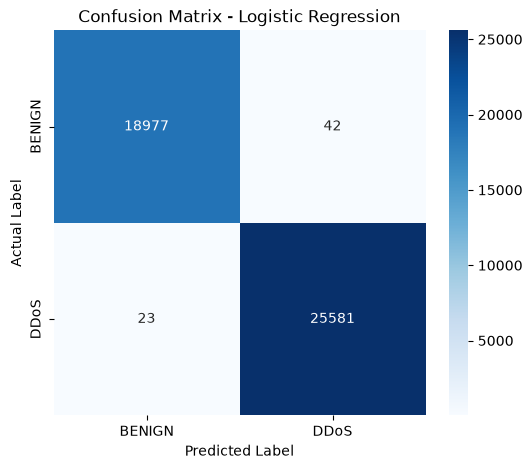

In [83]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["BENIGN", "DDoS"],
    yticklabels=["BENIGN", "DDoS"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()

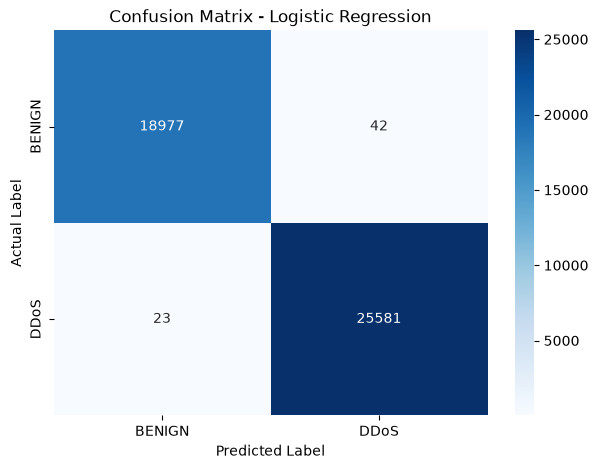

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["BENIGN", "DDoS"],
    yticklabels=["BENIGN", "DDoS"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()

In [85]:
import joblib

# Save the trained Logistic Regression model
joblib.dump(model, "../models/logistic_regression_model.pkl")

# Save the scaler
joblib.dump(scaler, "../models/scaler.pkl")

print("Model saved successfully!")
print("Scaler saved successfully!")

FileNotFoundError: [Errno 2] No such file or directory: '../models/logistic_regression_model.pkl'

In [86]:
import os

os.makedirs("../models", exist_ok=True)

print("Models folder created successfully!")

Models folder created successfully!


In [87]:
import joblib

# Save the trained Logistic Regression model
joblib.dump(model, "../models/logistic_regression_model.pkl")

# Save the scaler
joblib.dump(scaler, "../models/scaler.pkl")

print("Model saved successfully!")
print("Scaler saved successfully!")

Model saved successfully!
Scaler saved successfully!


In [88]:
print("Files in models folder:")

for file in os.listdir("../models"):
    print(file)

Files in models folder:
logistic_regression_model.pkl
scaler.pkl


In [89]:
import joblib

# Load saved model
loaded_model = joblib.load("../models/logistic_regression_model.pkl")

# Load saved scaler
loaded_scaler = joblib.load("../models/scaler.pkl")

print("Model loaded successfully!")
print("Scaler loaded successfully!")

Model loaded successfully!
Scaler loaded successfully!


In [90]:
# Verify loaded model on test data

loaded_X_test_scaled = loaded_scaler.transform(X_test)

loaded_predictions = loaded_model.predict(loaded_X_test_scaled)

print("Loaded model predictions completed!")
print("First 20 predictions:")
print(loaded_predictions[:20])

print("\nAccuracy of loaded model:")
print(accuracy_score(y_test, loaded_predictions))

Loaded model predictions completed!
First 20 predictions:
[1 1 0 1 0 1 0 0 0 1 1 1 1 0 0 0 1 1 1 1]

Accuracy of loaded model:
0.9985433520830065


In [91]:
print("Final dataset information:")
print("Rows:", len(df))
print("Columns:", len(df.columns))

print("\nMissing values:")
print(df.isnull().sum().sum())

print("\nInfinity values:")
print(np.isinf(df.select_dtypes(include=np.number)).sum().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nTarget classes:")
print(y.value_counts())

Final dataset information:
Rows: 223112
Columns: 79

Missing values:
0

Infinity values:
0

Duplicate rows:
0

Target classes:
Label
1    128016
0     95096
Name: count, dtype: int64


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Random Forest libraries imported successfully!")

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Random Forest libraries imported successfully!")

In [ ]:
print("Kernel is working!")

In [1]:
print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled:", X_test_scaled.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

NameError: name 'X_train_scaled' is not defined

In [2]:
X_train_scaled
X_test_scaled
y_train
y_test

NameError: name 'X_train_scaled' is not defined

In [3]:
print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled:", X_test_scaled.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

NameError: name 'X_train_scaled' is not defined

In [4]:
import pandas as pd
import numpy as np
import glob
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Find all dataset CSV files
csv_files = glob.glob("../data/raw/MachineLearningCSV/MachineLearningCVE/*.csv")

print("CSV files found:", len(csv_files))

# Load and combine all CSV files
df = pd.concat(
    [pd.read_csv(file) for file in csv_files],
    ignore_index=True
)

print("Original dataset shape:", df.shape)

# Clean column names
df.columns = df.columns.str.strip()

# Replace infinity values with NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Fill missing values
df["Flow Bytes/s"] = df["Flow Bytes/s"].fillna(0)

# Remove duplicate rows
df = df.drop_duplicates()

print("Cleaned dataset shape:", df.shape)

# Separate features and target
X = df.drop("Label", axis=1)
y = df["Label"]

# Encode target
y = y.map({
    "BENIGN": 0,
    "DDoS": 1
})

print("Target values:")
print(y.value_counts())

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

CSV files found: 8
Original dataset shape: (2830743, 79)
Cleaned dataset shape: (2522362, 79)
Target values:
Label
0.0    2096484
1.0     128016
Name: count, dtype: int64


ValueError: Input y contains NaN.

In [5]:
# Check missing and infinite values

print("Missing values in X:")
print(X.isnull().sum().sum())

print("\nInfinite values in X:")
print(np.isinf(X.select_dtypes(include=np.number)).sum().sum())

Missing values in X:
1564

Infinite values in X:
0


In [6]:
# Replace infinite values with NaN
X = X.replace([np.inf, -np.inf], np.nan)

# Fill missing values with 0
X = X.fillna(0)

print("Missing values after cleaning:", X.isnull().sum().sum())
print("Infinite values after cleaning:", np.isinf(X.select_dtypes(include=np.number)).sum().sum())

Missing values after cleaning: 0
Infinite values after cleaning: 0


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

ValueError: Input y contains NaN.

In [8]:
print("Total NaN values in X:")
print(X.isnull().sum().sum())

print("\nColumns containing NaN:")
print(X.isnull().sum()[X.isnull().sum() > 0])

Total NaN values in X:
0

Columns containing NaN:
Series([], dtype: int64)


In [9]:
from sklearn.model_selection import train_test_split

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

ValueError: Input y contains NaN.

In [10]:
print("NaN values in y:")
print(y.isnull().sum())

print("\nTarget values including NaN:")
print(y.value_counts(dropna=False))

NaN values in y:
297862

Target values including NaN:
Label
0.0    2096484
NaN     297862
1.0     128016
Name: count, dtype: int64


In [11]:
# Remove rows where target is NaN
valid_rows = y.notna()

X = X[valid_rows]
y = y[valid_rows]

print("NaN values in y after cleaning:", y.isnull().sum())
print("X shape:", X.shape)
print("y shape:", y.shape)

NaN values in y after cleaning: 0
X shape: (2224500, 78)
y shape: (2224500,)


In [12]:
print("Unique target values:")
print(y.unique())

print("\nTarget distribution:")
print(y.value_counts())

Unique target values:
[0. 1.]

Target distribution:
Label
0.0    2096484
1.0     128016
Name: count, dtype: int64


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (1779600, 78)
Testing features: (444900, 78)
Training target: (1779600,)
Testing target: (444900,)


In [14]:
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

print("Starting Random Forest training...")

# Train the model
rf_model.fit(X_train, y_train)

print("Random Forest training completed!")

Starting Random Forest training...
Random Forest training completed!


In [15]:
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

print("Starting Random Forest training...")

# Train the model
rf_model.fit(X_train, y_train)

print("Random Forest training completed!")

Starting Random Forest training...
Random Forest training completed!


In [16]:
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=50,
    random_state=42,
    n_jobs=-1,
    max_depth=20
)

print("Starting Random Forest training...")

# Train the model
rf_model.fit(X_train, y_train)

print("Random Forest training completed!")

Starting Random Forest training...
Random Forest training completed!


In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)

print("Starting Random Forest training...")

# Train the model
rf_model.fit(X_train, y_train)

print("Random Forest training completed!")

Starting Random Forest training...
Random Forest training completed!


In [18]:
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

print("Training Random Forest...")
rf_model.fit(X_train, y_train)

print("Random Forest training completed!")

Training Random Forest...
Random Forest training completed!


In [19]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Make predictions
rf_pred = rf_model.predict(X_test)

print("Random Forest predictions completed!")

# Accuracy
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)
print("Random Forest Accuracy (%):", rf_accuracy * 100)

# Classification report
print("\nRandom Forest Classification Report:")
print(classification_report(y_test, rf_pred))

Random Forest predictions completed!
Random Forest Accuracy: 0.9999775230388851
Random Forest Accuracy (%): 99.9977523038885

Random Forest Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    419297
         1.0       1.00      1.00      1.00     25603

    accuracy                           1.00    444900
   macro avg       1.00      1.00      1.00    444900
weighted avg       1.00      1.00      1.00    444900



Random Forest Confusion Matrix:
[[419296      1]
 [     9  25594]]


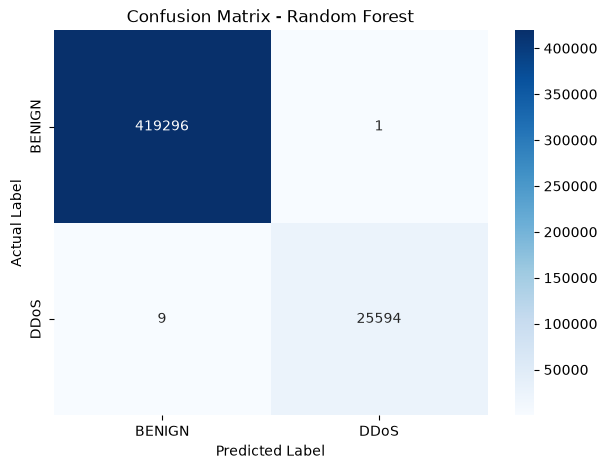

In [20]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Create confusion matrix
rf_cm = confusion_matrix(y_test, rf_pred)

print("Random Forest Confusion Matrix:")
print(rf_cm)

# Plot confusion matrix
plt.figure(figsize=(7, 5))
sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["BENIGN", "DDoS"],
    yticklabels=["BENIGN", "DDoS"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Random Forest")
plt.show()

In [21]:
import joblib
import os

# Save Random Forest model
joblib.dump(rf_model, "../models/random_forest_model.pkl")

print("Random Forest model saved successfully!")

Random Forest model saved successfully!


In [22]:
print("Files in models folder:")

for file in os.listdir("../models"):
    print(file)

Files in models folder:
logistic_regression_model.pkl
random_forest_model.pkl
scaler.pkl


In [23]:
# Random Forest Feature Importance

import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("Top 15 important features:")
print(feature_importance.head(15))

Top 15 important features:
Avg Bwd Segment Size           0.098295
Packet Length Variance         0.074014
Bwd Packet Length Max          0.073669
Max Packet Length              0.051898
Bwd Packet Length Std          0.051896
Packet Length Std              0.051615
Average Packet Size            0.038209
Subflow Fwd Packets            0.033309
act_data_pkt_fwd               0.033230
Bwd Packet Length Mean         0.032734
Subflow Fwd Bytes              0.031674
Total Length of Bwd Packets    0.029044
Total Fwd Packets              0.027840
Fwd Packet Length Mean         0.027018
Fwd Packet Length Max          0.021554
dtype: float64


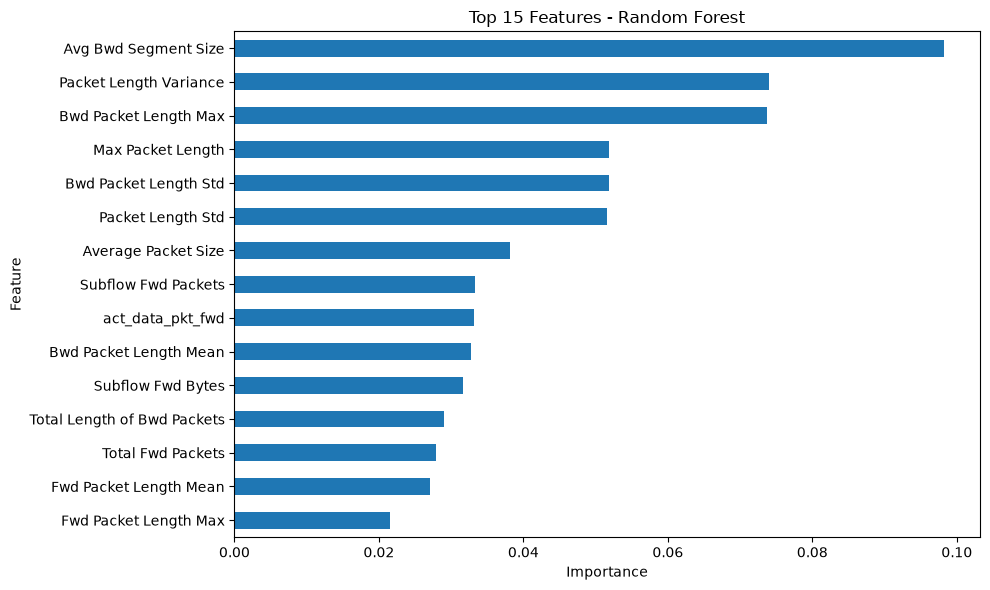

In [24]:
# Plot Top 15 Feature Importance

plt.figure(figsize=(10, 6))

feature_importance.head(15).sort_values().plot(kind="barh")

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Features - Random Forest")
plt.tight_layout()
plt.show()

In [25]:
import joblib
import os

# Create models folder if it doesn't exist
os.makedirs("../models", exist_ok=True)

# Save Random Forest model
joblib.dump(rf_model, "../models/random_forest_model.pkl")

print("Random Forest model saved successfully!")

Random Forest model saved successfully!


In [26]:
import joblib
import os

# Create models folder if it doesn't exist
os.makedirs("../models", exist_ok=True)

# Save Random Forest model
joblib.dump(rf_model, "../models/random_forest_model.pkl")

print("Random Forest model saved successfully!")

Random Forest model saved successfully!


In [27]:
import joblib

# Load saved Random Forest model
loaded_rf_model = joblib.load("../models/random_forest_model.pkl")

print("Random Forest model loaded successfully!")

Random Forest model loaded successfully!


In [28]:
# Verify loaded Random Forest model

rf_loaded_pred = loaded_rf_model.predict(X_test)

print("Loaded Random Forest predictions completed!")
print("First 20 predictions:")
print(rf_loaded_pred[:20])

print("\nLoaded Random Forest Accuracy:")
print(accuracy_score(y_test, rf_loaded_pred))

Loaded Random Forest predictions completed!
First 20 predictions:
[0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]

Loaded Random Forest Accuracy:
0.9999775230388851


In [29]:
# Compare model performance

lr_accuracy = accuracy_score(y_test, y_pred)
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Model Performance Comparison")
print("----------------------------")
print("Logistic Regression Accuracy:", lr_accuracy)
print("Random Forest Accuracy:", rf_accuracy)

print("\nAccuracy in percentage:")
print("Logistic Regression:", lr_accuracy * 100, "%")
print("Random Forest:", rf_accuracy * 100, "%")

NameError: name 'y_pred' is not defined

In [30]:
# Compare Logistic Regression and Random Forest performance

lr_loaded_pred = loaded_model.predict(loaded_X_test_scaled)

lr_accuracy = accuracy_score(y_test, lr_loaded_pred)
rf_accuracy = accuracy_score(y_test, rf_loaded_pred)

print("Model Performance Comparison")
print("----------------------------")

print("Logistic Regression Accuracy:", lr_accuracy)
print("Random Forest Accuracy:", rf_accuracy)

print("\nAccuracy in percentage:")
print("Logistic Regression:", lr_accuracy * 100, "%")
print("Random Forest:", rf_accuracy * 100, "%")

NameError: name 'loaded_model' is not defined

In [31]:
import joblib
from sklearn.metrics import accuracy_score

# Load Logistic Regression model
loaded_model = joblib.load("../models/logistic_regression_model.pkl")

# Load scaler
loaded_scaler = joblib.load("../models/scaler.pkl")

# Load Random Forest model
loaded_rf_model = joblib.load("../models/random_forest_model.pkl")

# Scale test data for Logistic Regression
loaded_X_test_scaled = loaded_scaler.transform(X_test)

# Logistic Regression predictions
lr_loaded_pred = loaded_model.predict(loaded_X_test_scaled)

# Random Forest predictions
rf_loaded_pred = loaded_rf_model.predict(X_test)

# Calculate accuracy
lr_accuracy = accuracy_score(y_test, lr_loaded_pred)
rf_accuracy = accuracy_score(y_test, rf_loaded_pred)

# Display comparison
print("Model Performance Comparison")
print("----------------------------")

print("Logistic Regression Accuracy:", lr_accuracy)
print("Random Forest Accuracy:", rf_accuracy)

print("\nAccuracy in percentage:")
print("Logistic Regression:", lr_accuracy * 100, "%")
print("Random Forest:", rf_accuracy * 100, "%")

Model Performance Comparison
----------------------------
Logistic Regression Accuracy: 0.9937334232411777
Random Forest Accuracy: 0.9999775230388851

Accuracy in percentage:
Logistic Regression: 99.37334232411777 %
Random Forest: 99.9977523038885 %


In [32]:
import xgboost as xgb

print("XGBoost version:", xgb.__version__)
print("XGBoost imported successfully!")

XGBoost version: 3.4.1
XGBoost imported successfully!


In [33]:
from sklearn.metrics import accuracy_score

# Logistic Regression
lr_train_pred = loaded_model.predict(X_train_scaled)
lr_test_pred = loaded_model.predict(loaded_X_test_scaled)

lr_train_accuracy = accuracy_score(y_train, lr_train_pred)
lr_test_accuracy = accuracy_score(y_test, lr_test_pred)

# Random Forest
rf_train_pred = rf_model.predict(X_train)
rf_test_pred = rf_model.predict(X_test)

rf_train_accuracy = accuracy_score(y_train, rf_train_pred)
rf_test_accuracy = accuracy_score(y_test, rf_test_pred)

print("Training vs Testing Accuracy")
print("--------------------------------")

print("Logistic Regression Training Accuracy:", lr_train_accuracy)
print("Logistic Regression Testing Accuracy:", lr_test_accuracy)

print()

print("Random Forest Training Accuracy:", rf_train_accuracy)
print("Random Forest Testing Accuracy:", rf_test_accuracy)

NameError: name 'X_train_scaled' is not defined

In [34]:
import joblib
from sklearn.metrics import accuracy_score

# Load saved Logistic Regression model
loaded_model = joblib.load("../models/logistic_regression_model.pkl")

# Load saved scaler
loaded_scaler = joblib.load("../models/scaler.pkl")

# Scale training and testing data
X_train_scaled = loaded_scaler.transform(X_train)
X_test_scaled = loaded_scaler.transform(X_test)

print("Training and testing data scaled successfully!")
print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled:", X_test_scaled.shape)

Training and testing data scaled successfully!
X_train_scaled: (1779600, 78)
X_test_scaled: (444900, 78)


In [35]:
from sklearn.metrics import accuracy_score

# Logistic Regression predictions
lr_train_pred = loaded_model.predict(X_train_scaled)
lr_test_pred = loaded_model.predict(X_test_scaled)

# Calculate accuracy
lr_train_accuracy = accuracy_score(y_train, lr_train_pred)
lr_test_accuracy = accuracy_score(y_test, lr_test_pred)

print("Logistic Regression")
print("-----------------------------")
print("Training Accuracy:", lr_train_accuracy)
print("Testing Accuracy:", lr_test_accuracy)

print("\nAccuracy in percentage:")
print("Training:", lr_train_accuracy * 100, "%")
print("Testing:", lr_test_accuracy * 100, "%")

Logistic Regression
-----------------------------
Training Accuracy: 0.9937086985839515
Testing Accuracy: 0.9937334232411777

Accuracy in percentage:
Training: 99.37086985839515 %
Testing: 99.37334232411777 %


In [36]:
# Random Forest predictions

rf_train_pred = loaded_rf_model.predict(X_train)
rf_test_pred = loaded_rf_model.predict(X_test)

# Calculate accuracy
rf_train_accuracy = accuracy_score(y_train, rf_train_pred)
rf_test_accuracy = accuracy_score(y_test, rf_test_pred)

print("Random Forest")
print("---------------------------")
print("Training Accuracy:", rf_train_accuracy)
print("Testing Accuracy:", rf_test_accuracy)

print("\nAccuracy in percentage:")
print("Training:", rf_train_accuracy * 100, "%")
print("Testing:", rf_test_accuracy * 100, "%")

Random Forest
---------------------------
Training Accuracy: 0.9999983142279164
Testing Accuracy: 0.9999775230388851

Accuracy in percentage:
Training: 99.99983142279164 %
Testing: 99.9977523038885 %


In [37]:
import joblib
import numpy as np

# Load saved model
rf_model = joblib.load("../models/random_forest_model.pkl")

# Load saved scaler
scaler = joblib.load("../models/scaler.pkl")

print("Random Forest model loaded!")
print("Scaler loaded!")

Random Forest model loaded!
Scaler loaded!


In [38]:
# Function to predict whether network traffic is BENIGN or DDoS

def predict_traffic(input_data):

    # Convert input data to NumPy array
    input_array = np.array(input_data).reshape(1, -1)

    # Scale the input using the saved scaler
    input_scaled = scaler.transform(input_array)

    # Make prediction
    prediction = rf_model.predict(input_scaled)

    # Convert prediction to readable label
    if prediction[0] == 0:
        return "BENIGN"
    else:
        return "DDoS"


print("Prediction function created successfully!")

Prediction function created successfully!


In [39]:
# Test prediction function

sample = X_test.iloc[0].values

result = predict_traffic(sample)

print("Prediction:", result)

Prediction: BENIGN


C:\Users\Admin\OneDrive\Documents\AI-Net\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\Admin\OneDrive\Documents\AI-Net\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [40]:
# Test multiple network traffic samples

samples = X_test.iloc[:10].values

print("Testing 10 network traffic samples:\n")

for i, sample in enumerate(samples):
    result = predict_traffic(sample)
    print(f"Sample {i+1}: {result}")

Testing 10 network traffic samples:

Sample 1: BENIGN
Sample 2: BENIGN
Sample 3: BENIGN
Sample 4: BENIGN
Sample 5: BENIGN
Sample 6: BENIGN
Sample 7: BENIGN
Sample 8: BENIGN
Sample 9: BENIGN
Sample 10: BENIGN


C:\Users\Admin\OneDrive\Documents\AI-Net\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\Admin\OneDrive\Documents\AI-Net\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Admin\OneDrive\Documents\AI-Net\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\Admin\OneDrive\Documents\AI-Net\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\Admin\OneDrive\Documents\AI-Net\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have v

In [41]:
import pandas as pd
import numpy as np

def predict_traffic(input_data):

    # Convert input to DataFrame while keeping feature names
    if isinstance(input_data, pd.Series):
        input_df = input_data.to_frame().T
    elif isinstance(input_data, pd.DataFrame):
        input_df = input_data.copy()
    else:
        input_df = pd.DataFrame(
            [input_data],
            columns=X_test.columns
        )

    # Scale input
    input_scaled_array = scaler.transform(input_df)

    # Convert scaled data back to DataFrame
    input_scaled = pd.DataFrame(
        input_scaled_array,
        columns=X_test.columns
    )

    # Make prediction
    prediction = rf_model.predict(input_scaled)

    # Convert prediction to readable label
    if prediction[0] == 0:
        return "BENIGN"
    else:
        return "DDoS"


print("Prediction function updated successfully!")

Prediction function updated successfully!


In [42]:
sample = X_test.iloc[0]

result = predict_traffic(sample)

print("Prediction:", result)

Prediction: BENIGN


In [43]:
# Find a DDoS sample from the test dataset
ddos_sample = X_test[y_test == 1].iloc[0]

# Predict the sample
result = predict_traffic(ddos_sample)

print("Actual Label: DDoS")
print("Predicted Label:", result)

Actual Label: DDoS
Predicted Label: BENIGN


In [44]:
# Prediction function for Random Forest
def predict_traffic(input_data):

    # Convert input to DataFrame
    input_df = pd.DataFrame(
        [input_data],
        columns=X_test.columns
    )

    # Random Forest was trained on UN-SCALED data
    prediction = rf_model.predict(input_df)

    # Convert prediction to readable label
    if prediction[0] == 0:
        return "BENIGN"
    else:
        return "DDoS"


print("Prediction function fixed successfully!")

Prediction function fixed successfully!


In [45]:
sample = X_test.iloc[0]

result = predict_traffic(sample)

print("Prediction:", result)

Prediction: BENIGN


In [46]:
ddos_sample = X_test[y_test == 1].iloc[0]

result = predict_traffic(ddos_sample)

print("Actual Label: DDoS")
print("Predicted Label:", result)

Actual Label: DDoS
Predicted Label: DDoS


In [47]:
# Correct prediction function for Random Forest

def predict_traffic(input_data):

    # Convert input to DataFrame
    input_df = pd.DataFrame(
        [input_data],
        columns=X_test.columns
    )

    # Random Forest was trained on unscaled data
    prediction = rf_model.predict(input_df)

    # Convert prediction to readable label
    if prediction[0] == 0:
        return "BENIGN"
    else:
        return "DDoS"


print("Prediction function fixed successfully!")

Prediction function fixed successfully!


In [48]:
# Test BENIGN sample

sample = X_test.iloc[0]

result = predict_traffic(sample)

print("Actual Label:", "BENIGN" if y_test.iloc[0] == 0 else "DDoS")
print("Predicted Label:", result)

Actual Label: BENIGN
Predicted Label: BENIGN


In [49]:
# Test DDoS sample

ddos_sample = X_test[y_test == 1].iloc[0]

result = predict_traffic(ddos_sample)

print("Actual Label: DDoS")
print("Predicted Label:", result)

Actual Label: DDoS
Predicted Label: DDoS


In [50]:
pip install streamlit

   ---------------------------------------- 0.0/10.5 MB ? eta -:--:--
   - -------------------------------------- 0.5/10.5 MB 4.7 MB/s eta 0:00:03
   ---- ----------------------------------- 1.3/10.5 MB 4.3 MB/s eta 0:00:03
   -------- ------------------------------- 2.4/10.5 MB 4.0 MB/s eta 0:00:03
   ------------- -------------------------- 3.7/10.5 MB 4.7 MB/s eta 0:00:02
   ----------------- ---------------------- 4.7/10.5 MB 4.8 MB/s eta 0:00:02
   ------------------- -------------------- 5.2/10.5 MB 4.5 MB/s eta 0:00:02
   ----------------------- ---------------- 6.3/10.5 MB 4.5 MB/s eta 0:00:01
   ------------------------- -------------- 6.8/10.5 MB 4.3 MB/s eta 0:00:01
   ------------------------------ --------- 8.1/10.5 MB 4.5 MB/s eta 0:00:01
   ---------------------------------- ----- 9.2/10.5 MB 4.5 MB/s eta 0:00:01
   -------------------------------------- - 10.2/10.5 MB 4.6 MB/s eta 0:00:01
   ---------------------------------------- 10.5/10.5 MB 4.6 MB/s  0:00:02
   ----

In [51]:
from flask import Flask, request, jsonify, render_template
import joblib
import pandas as pd
import os

app = Flask(__name__)

# ==============================
# Load trained Random Forest model
# ==============================

MODEL_PATH = os.path.join("models", "random_forest_model.pkl")

rf_model = joblib.load(MODEL_PATH)

print("Random Forest model loaded successfully!")


# ==============================
# Home page
# ==============================

@app.route("/")
def home():
    return render_template("index.html")


# ==============================
# Prediction API
# ==============================

@app.route("/predict", methods=["POST"])
def predict():

    try:
        # Get JSON data from frontend
        data = request.get_json()

        # Check input
        if data is None:
            return jsonify({
                "error": "No input data received"
            }), 400

        # Get feature names from trained model
        feature_names = rf_model.feature_names_in_

        # Convert input to DataFrame
        input_df = pd.DataFrame(
            [data],
            columns=feature_names
        )

        # Make prediction
        prediction = rf_model.predict(input_df)

        # Convert prediction to readable label
        if prediction[0] == 0:
            result = "BENIGN"
        else:
            result = "DDoS"

        return jsonify({
            "prediction": result
        })

    except Exception as e:

        return jsonify({
            "error": str(e)
        }), 500


# ==============================
# Run Flask application
# ==============================

if __name__ == "__main__":
    app.run(debug=True)

ModuleNotFoundError: No module named 'flask'

In [52]:
# Get one DDoS sample for testing the web application

ddos_sample = X_test[y_test == 1].iloc[0].values

print("DDoS sample:")
print(ddos_sample)

print("\nNumber of features:", len(ddos_sample))

DDoS sample:
[8.00000000e+01 3.08632000e+05 3.00000000e+00 5.00000000e+00
 2.60000000e+01 1.16070000e+04 2.00000000e+01 0.00000000e+00
 8.66666667e+00 1.02632029e+01 7.21500000e+03 0.00000000e+00
 2.32140000e+03 3.32776979e+03 3.76921382e+04 2.59208378e+01
 4.40902857e+04 1.16302826e+05 3.07840000e+05 4.00000000e+00
 6.66000000e+02 3.33000000e+02 3.33754401e+02 5.69000000e+02
 9.70000000e+01 3.08584000e+05 7.71460000e+04 1.53796268e+05
 3.07840000e+05 4.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 7.20000000e+01 1.12000000e+02
 9.72031416e+00 1.62005236e+01 0.00000000e+00 7.21500000e+03
 1.29255556e+03 2.65058565e+03 7.02560428e+06 0.00000000e+00
 0.00000000e+00 0.00000000e+00 1.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 1.00000000e+00
 1.45412500e+03 8.66666667e+00 2.32140000e+03 7.20000000e+01
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 3.00000000e+00 2.60000000e+01
 5.00000000

In [53]:
# Convert DDoS sample into comma-separated values
ddos_input = ",".join(map(str, ddos_sample))

print("Copy the following 78 values:")
print(ddos_input)

Copy the following 78 values:
80.0,308632.0,3.0,5.0,26.0,11607.0,20.0,0.0,8.666666667,10.26320288,7215.0,0.0,2321.4,3327.769794,37692.13821,25.92083776,44090.28571,116302.8265,307840.0,4.0,666.0,333.0,333.7544007,569.0,97.0,308584.0,77146.0,153796.2679,307840.0,4.0,0.0,0.0,0.0,0.0,72.0,112.0,9.720314161,16.2005236,0.0,7215.0,1292.555556,2650.585648,7025604.278,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1454.125,8.666666667,2321.4,72.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,26.0,5.0,11607.0,8192.0,229.0,2.0,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [54]:
# Get one DDoS sample and convert it to comma-separated format

ddos_sample = X_test[y_test == 1].iloc[0].values

ddos_input = ",".join(map(str, ddos_sample))

print(ddos_input)

80.0,308632.0,3.0,5.0,26.0,11607.0,20.0,0.0,8.666666667,10.26320288,7215.0,0.0,2321.4,3327.769794,37692.13821,25.92083776,44090.28571,116302.8265,307840.0,4.0,666.0,333.0,333.7544007,569.0,97.0,308584.0,77146.0,153796.2679,307840.0,4.0,0.0,0.0,0.0,0.0,72.0,112.0,9.720314161,16.2005236,0.0,7215.0,1292.555556,2650.585648,7025604.278,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1454.125,8.666666667,2321.4,72.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,26.0,5.0,11607.0,8192.0,229.0,2.0,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [55]:
print("Unique y_test values:")
print(np.unique(y_test, return_counts=True))

print("\nSample labels:")
print(y_test[:20])

Unique y_test values:
(array([0., 1.]), array([419297,  25603]))

Sample labels:
818772     0.0
1847090    0.0
965236     0.0
1278535    0.0
1541888    0.0
1138204    0.0
29842      1.0
1124726    0.0
852729     0.0
2706478    0.0
1805336    0.0
2065177    0.0
1487120    0.0
970018     0.0
243216     0.0
2007327    0.0
118903     1.0
2112392    0.0
1025319    0.0
42707      0.0
Name: Label, dtype: float64


In [56]:
# Check how the model predicts the DDoS sample

prediction = rf_model.predict([ddos_sample])

print("Actual label:", 1)
print("Model prediction:", prediction[0])

if prediction[0] == 1:
    print("✅ Correctly classified as DDoS")
else:
    print("❌ Misclassified as BENIGN")

C:\Users\Admin\OneDrive\Documents\AI-Net\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


Actual label: 1
Model prediction: 1.0
✅ Correctly classified as DDoS


In [57]:
# Find a DDoS sample that the model correctly predicts

test_predictions = rf_model.predict(X_test)

correct_ddos = (y_test.values == 1) & (test_predictions == 1)

print("Correctly predicted DDoS samples:", correct_ddos.sum())

Correctly predicted DDoS samples: 25594


In [58]:
# Find one DDoS sample that the model predicts correctly

test_predictions = rf_model.predict(X_test)

correct_ddos = (y_test.values == 1) & (test_predictions == 1)

ddos_index = X_test.index[correct_ddos][0]

ddos_input = X_test.loc[ddos_index].values

print("DDoS sample with 78 features:")
print(",".join(map(str, ddos_input)))

print("\nNumber of features:", len(ddos_input))

DDoS sample with 78 features:
80.0,308632.0,3.0,5.0,26.0,11607.0,20.0,0.0,8.666666667,10.26320288,7215.0,0.0,2321.4,3327.769794,37692.13821,25.92083776,44090.28571,116302.8265,307840.0,4.0,666.0,333.0,333.7544007,569.0,97.0,308584.0,77146.0,153796.2679,307840.0,4.0,0.0,0.0,0.0,0.0,72.0,112.0,9.720314161,16.2005236,0.0,7215.0,1292.555556,2650.585648,7025604.278,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1454.125,8.666666667,2321.4,72.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,26.0,5.0,11607.0,8192.0,229.0,2.0,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0

Number of features: 78


In [59]:
# Find one BENIGN sample that the model predicts correctly

test_predictions = rf_model.predict(X_test)

correct_benign = (y_test.values == 0) & (test_predictions == 0)

print("Correctly predicted BENIGN samples:", correct_benign.sum())

Correctly predicted BENIGN samples: 419296


In [60]:
# Get one correctly predicted BENIGN sample

benign_index = X_test.index[correct_benign][0]

benign_sample = X_test.loc[benign_index].values

benign_input = ",".join(map(str, benign_sample))

print("Copy the following values into the web app:")
print(benign_input)
print("\nNumber of features:", len(benign_sample))

Copy the following values into the web app:
53.0,48002.0,1.0,1.0,46.0,90.0,46.0,46.0,46.0,0.0,90.0,90.0,90.0,0.0,2833.2152826966,41.6649306279,48002.0,0.0,48002.0,48002.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,32.0,32.0,20.8324653139,20.8324653139,46.0,90.0,60.6666666667,25.4034118443,645.3333333333,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,91.0,46.0,90.0,32.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,46.0,1.0,90.0,-1.0,-1.0,0.0,32.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0

Number of features: 78


In [61]:
# Get one DDoS sample
ddos_sample = X_test[y_test == 1].iloc[0].values

# Convert to comma-separated values
ddos_input = ",".join(map(str, ddos_sample))

print("Copy these 78 values:")
print(ddos_input)

Copy these 78 values:
80.0,308632.0,3.0,5.0,26.0,11607.0,20.0,0.0,8.666666667,10.26320288,7215.0,0.0,2321.4,3327.769794,37692.13821,25.92083776,44090.28571,116302.8265,307840.0,4.0,666.0,333.0,333.7544007,569.0,97.0,308584.0,77146.0,153796.2679,307840.0,4.0,0.0,0.0,0.0,0.0,72.0,112.0,9.720314161,16.2005236,0.0,7215.0,1292.555556,2650.585648,7025604.278,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1454.125,8.666666667,2321.4,72.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,26.0,5.0,11607.0,8192.0,229.0,2.0,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [62]:
# Get one BENIGN sample
benign_sample = X_test[y_test == 0].iloc[0].values

# Convert to comma-separated values
benign_input = ",".join(map(str, benign_sample))

print("Copy these values into the web app:")
print(benign_input)

Copy these values into the web app:
53.0,48002.0,1.0,1.0,46.0,90.0,46.0,46.0,46.0,0.0,90.0,90.0,90.0,0.0,2833.2152826966,41.6649306279,48002.0,0.0,48002.0,48002.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,32.0,32.0,20.8324653139,20.8324653139,46.0,90.0,60.6666666667,25.4034118443,645.3333333333,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,91.0,46.0,90.0,32.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,46.0,1.0,90.0,-1.0,-1.0,0.0,32.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [63]:
# Test model accuracy on the complete test dataset

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Make predictions
y_pred = rf_model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)
print("Model Accuracy (%):", accuracy * 100)

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Model Accuracy: 0.9999775230388851
Model Accuracy (%): 99.9977523038885

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    419297
         1.0       1.00      1.00      1.00     25603

    accuracy                           1.00    444900
   macro avg       1.00      1.00      1.00    444900
weighted avg       1.00      1.00      1.00    444900


Confusion Matrix:
[[419296      1]
 [     9  25594]]


In [64]:
# Final model evaluation summary

print("========== AI-Net Model Evaluation ==========")
print(f"Accuracy: {accuracy * 100:.4f}%")
print(f"Total Test Samples: {len(y_test)}")
print(f"Correct Predictions: {(y_test == y_pred).sum()}")
print(f"Incorrect Predictions: {(y_test != y_pred).sum()}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

========== AI-Net Model Evaluation ==========
Accuracy: 99.9978%
Total Test Samples: 444900
Correct Predictions: 444890
Incorrect Predictions: 10

Confusion Matrix:
[[419296      1]
 [     9  25594]]

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    419297
         1.0       1.00      1.00      1.00     25603

    accuracy                           1.00    444900
   macro avg       1.00      1.00      1.00    444900
weighted avg       1.00      1.00      1.00    444900



In [65]:
# AI-Net Final Model Summary

print("=" * 50)
print("AI-Net FINAL MODEL SUMMARY")
print("=" * 50)

print(f"Accuracy: {accuracy * 100:.4f}%")
print(f"Total Test Samples: {len(y_test)}")
print(f"Correct Predictions: {(y_test == y_pred).sum()}")
print(f"Incorrect Predictions: {(y_test != y_pred).sum()}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClass Distribution:")
print("BENIGN:", (y_test == 0).sum())
print("DDoS:", (y_test == 1).sum())

print("\nModel: Random Forest")
print("Task: Network Intrusion Detection")
print("Classes: BENIGN / DDoS")

print("=" * 50)

AI-Net FINAL MODEL SUMMARY
Accuracy: 99.9978%
Total Test Samples: 444900
Correct Predictions: 444890
Incorrect Predictions: 10

Confusion Matrix:
[[419296      1]
 [     9  25594]]

Class Distribution:
BENIGN: 419297
DDoS: 25603

Model: Random Forest
Task: Network Intrusion Detection
Classes: BENIGN / DDoS


In [66]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Get feature importance from Random Forest
importance = rf_model.feature_importances_

# Get feature names
feature_names = rf_model.feature_names_in_

# Create DataFrame
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

# Sort by importance
feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

# Display top 20 features
print("Top 20 Important Features:")
print(feature_importance_df.head(20))

Top 20 Important Features:
                        Feature  Importance
54         Avg Bwd Segment Size    0.098295
42       Packet Length Variance    0.074014
10        Bwd Packet Length Max    0.073669
39            Max Packet Length    0.051898
13        Bwd Packet Length Std    0.051896
41            Packet Length Std    0.051615
52          Average Packet Size    0.038209
62          Subflow Fwd Packets    0.033309
68             act_data_pkt_fwd    0.033230
12       Bwd Packet Length Mean    0.032734
63            Subflow Fwd Bytes    0.031674
5   Total Length of Bwd Packets    0.029044
2             Total Fwd Packets    0.027840
8        Fwd Packet Length Mean    0.027018
6         Fwd Packet Length Max    0.021554
3        Total Backward Packets    0.020962
4   Total Length of Fwd Packets    0.020676
35            Bwd Header Length    0.020412
40           Packet Length Mean    0.019366
22                  Fwd IAT Std    0.018656


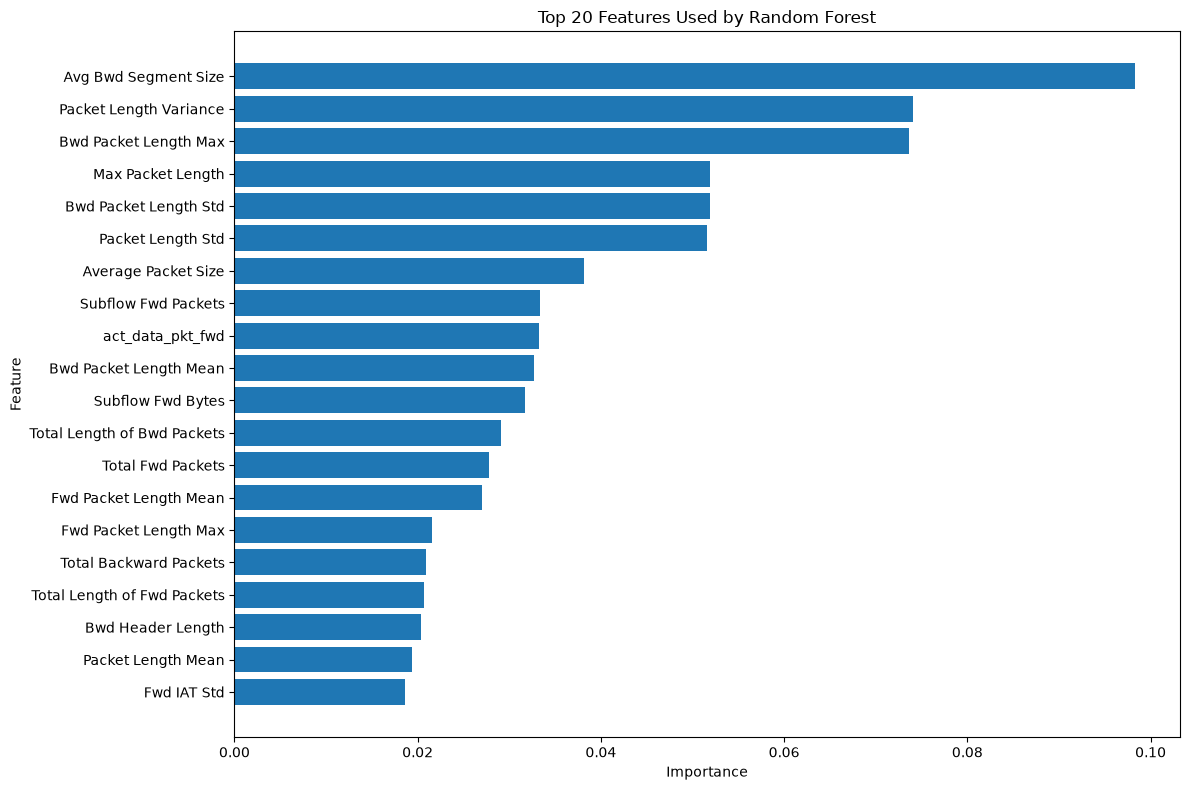

In [67]:
# Plot top 20 important features

top_features = feature_importance_df.head(20)

plt.figure(figsize=(12, 8))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 20 Features Used by Random Forest")

plt.tight_layout()

plt.show()

In [68]:
# Display the Top 10 Most Important Features

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Top 10 Most Important Features:")
print(feature_importance.head(10).to_string(index=False))

Top 10 Most Important Features:
               Feature  Importance
  Avg Bwd Segment Size    0.098295
Packet Length Variance    0.074014
 Bwd Packet Length Max    0.073669
     Max Packet Length    0.051898
 Bwd Packet Length Std    0.051896
     Packet Length Std    0.051615
   Average Packet Size    0.038209
   Subflow Fwd Packets    0.033309
      act_data_pkt_fwd    0.033230
Bwd Packet Length Mean    0.032734


In [69]:
# ============================================
# AI-Net - Feature Importance Analysis
# ============================================

# Get feature importance values
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
})

# Sort from highest to lowest
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

# Display top 20 features
print("Top 20 Features Used by Random Forest:")
print(importance_df.head(20).to_string(index=False))

Top 20 Features Used by Random Forest:
                    Feature  Importance
       Avg Bwd Segment Size    0.098295
     Packet Length Variance    0.074014
      Bwd Packet Length Max    0.073669
          Max Packet Length    0.051898
      Bwd Packet Length Std    0.051896
          Packet Length Std    0.051615
        Average Packet Size    0.038209
        Subflow Fwd Packets    0.033309
           act_data_pkt_fwd    0.033230
     Bwd Packet Length Mean    0.032734
          Subflow Fwd Bytes    0.031674
Total Length of Bwd Packets    0.029044
          Total Fwd Packets    0.027840
     Fwd Packet Length Mean    0.027018
      Fwd Packet Length Max    0.021554
     Total Backward Packets    0.020962
Total Length of Fwd Packets    0.020676
          Bwd Header Length    0.020412
         Packet Length Mean    0.019366
                Fwd IAT Std    0.018656


In [70]:
# ============================================
# DAY 7 - FEATURE IMPORTANCE ANALYSIS
# Select Top 10 Features
# ============================================

# Get top 10 most important features
top_features = importance_df.head(10)

print("Top 10 Features Selected:")
print(top_features.to_string(index=False))

Top 10 Features Selected:
               Feature  Importance
  Avg Bwd Segment Size    0.098295
Packet Length Variance    0.074014
 Bwd Packet Length Max    0.073669
     Max Packet Length    0.051898
 Bwd Packet Length Std    0.051896
     Packet Length Std    0.051615
   Average Packet Size    0.038209
   Subflow Fwd Packets    0.033309
      act_data_pkt_fwd    0.033230
Bwd Packet Length Mean    0.032734


In [71]:
# ============================================
# DAY 7 - FEATURE SELECTION
# Select Top 10 Features
# ============================================

selected_features = top_features["Feature"].tolist()

print("Selected Features:")
for i, feature in enumerate(selected_features, 1):
    print(i, feature)

print("\nNumber of selected features:", len(selected_features))

Selected Features:
1 Avg Bwd Segment Size
2 Packet Length Variance
3 Bwd Packet Length Max
4 Max Packet Length
5 Bwd Packet Length Std
6 Packet Length Std
7 Average Packet Size
8 Subflow Fwd Packets
9 act_data_pkt_fwd
10 Bwd Packet Length Mean

Number of selected features: 10


In [72]:
# ============================================
# DAY 7 - FEATURE SELECTION
# Create dataset using only Top 10 features
# ============================================

X_selected = X[selected_features]

print("Original number of features:", X.shape[1])
print("Selected number of features:", X_selected.shape[1])

print("\nSelected dataset shape:")
print(X_selected.shape)

print("\nSelected feature names:")
print(X_selected.columns.tolist())

Original number of features: 78
Selected number of features: 10

Selected dataset shape:
(2224500, 10)

Selected feature names:
['Avg Bwd Segment Size', 'Packet Length Variance', 'Bwd Packet Length Max', 'Max Packet Length', 'Bwd Packet Length Std', 'Packet Length Std', 'Average Packet Size', 'Subflow Fwd Packets', 'act_data_pkt_fwd', 'Bwd Packet Length Mean']


In [73]:
# ==========================================
# DAY 7 - RETRAIN MODEL WITH 10 FEATURES
# ==========================================

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Split selected features into training and testing data
X_train_selected, X_test_selected, y_train_selected, y_test_selected = train_test_split(
    X_selected,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Selected Training Data Shape:", X_train_selected.shape)
print("Selected Testing Data Shape:", X_test_selected.shape)

# Create Random Forest model
rf_selected = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Train model
print("\nTraining Random Forest with 10 selected features...")

rf_selected.fit(X_train_selected, y_train_selected)

print("Training completed successfully!")

Selected Training Data Shape: (1779600, 10)
Selected Testing Data Shape: (444900, 10)

Training Random Forest with 10 selected features...
Training completed successfully!


In [74]:
# ============================================
# DAY 7 - EVALUATE MODEL WITH 10 FEATURES
# ============================================

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("=" * 50)
print("AI-Net - Selected Feature Model Evaluation")
print("=" * 50)

# Make predictions
y_pred_selected = rf_selected.predict(X_test_selected)

# Calculate accuracy
accuracy_selected = accuracy_score(y_test_selected, y_pred_selected)

print("\nAccuracy:", accuracy_selected)
print("Accuracy (%):", accuracy_selected * 100)

# Count correct and incorrect predictions
correct_predictions = (y_pred_selected == y_test_selected).sum()
incorrect_predictions = (y_pred_selected != y_test_selected).sum()

print("\nTotal Test Samples:", len(y_test_selected))
print("Correct Predictions:", correct_predictions)
print("Incorrect Predictions:", incorrect_predictions)

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_selected, y_pred_selected))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test_selected, y_pred_selected))

AI-Net - Selected Feature Model Evaluation

Accuracy: 0.999763991908294
Accuracy (%): 99.9763991908294

Total Test Samples: 444900
Correct Predictions: 444795
Incorrect Predictions: 105

Confusion Matrix:
[[419232     65]
 [    40  25563]]

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    419297
         1.0       1.00      1.00      1.00     25603

    accuracy                           1.00    444900
   macro avg       1.00      1.00      1.00    444900
weighted avg       1.00      1.00      1.00    444900



In [75]:
# ==========================================
# DAY 7 - FULL MODEL vs SELECTED MODEL
# ==========================================

print("=" * 60)
print("AI-Net - Model Comparison")
print("=" * 60)

# Full model predictions
y_pred_full = rf_model.predict(X_test)

# Selected-feature model predictions
y_pred_selected = rf_selected.predict(X_test_selected)

# Calculate accuracies
full_accuracy = accuracy_score(y_test, y_pred_full)
selected_accuracy = accuracy_score(y_test_selected, y_pred_selected)

print("\nFull Feature Model (78 Features)")
print("Accuracy:", full_accuracy)
print("Accuracy (%):", full_accuracy * 100)

print("\nSelected Feature Model (10 Features)")
print("Accuracy:", selected_accuracy)
print("Accuracy (%):", selected_accuracy * 100)

print("\nAccuracy Difference:")
print((full_accuracy - selected_accuracy) * 100, "%")

print("\n" + "=" * 60)

AI-Net - Model Comparison

Full Feature Model (78 Features)
Accuracy: 0.9999775230388851
Accuracy (%): 99.9977523038885

Selected Feature Model (10 Features)
Accuracy: 0.999763991908294
Accuracy (%): 99.9763991908294

Accuracy Difference:
0.021353113059108253 %



In [76]:
# ==========================================
# DAY 7 - MODEL EFFICIENCY COMPARISON
# ==========================================

import time

print("=" * 60)
print("AI-Net - Model Efficiency Comparison")
print("=" * 60)

# Number of features
print("\nFull Feature Model:")
print("Features:", X_train.shape[1])

print("\nSelected Feature Model:")
print("Features:", X_train_selected.shape[1])

# Measure prediction time - Full model
start_time = time.time()

full_predictions = rf_model.predict(X_test)

full_time = time.time() - start_time

# Measure prediction time - Selected model
start_time = time.time()

selected_predictions = rf_selected.predict(X_test_selected)

selected_time = time.time() - start_time

# Display results
print("\nPrediction Time Comparison:")
print("--------------------------------")

print("Full Model Prediction Time:",
      round(full_time, 4), "seconds")

print("Selected Model Prediction Time:",
      round(selected_time, 4), "seconds")

# Calculate improvement
if full_time > 0:
    improvement = ((full_time - selected_time) / full_time) * 100
else:
    improvement = 0

print("\nPrediction Time Improvement:",
      round(improvement, 2), "%")

print("=" * 60)

AI-Net - Model Efficiency Comparison

Full Feature Model:
Features: 78

Selected Feature Model:
Features: 10

Prediction Time Comparison:
--------------------------------
Full Model Prediction Time: 1.478 seconds
Selected Model Prediction Time: 0.7327 seconds

Prediction Time Improvement: 50.43 %


In [77]:
# ============================================================
# DAY 8 - HYPERPARAMETER TUNING
# ============================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import time

print("=" * 60)
print("AI-Net - Day 8: Hyperparameter Tuning")
print("=" * 60)

# Baseline model
print("\nBaseline Model:")
print("Estimators: 100")
print("Max Depth: None")

# Test different numbers of trees
n_estimators_list = [50, 100, 150, 200]

results = []

for n in n_estimators_list:

    print(f"\nTraining Random Forest with {n} trees...")

    model = RandomForestClassifier(
        n_estimators=n,
        random_state=42,
        n_jobs=-1
    )

    start_time = time.time()

    model.fit(X_train_selected, y_train_selected)

    training_time = time.time() - start_time

    y_pred = model.predict(X_test_selected)

    accuracy = accuracy_score(y_test_selected, y_pred)

    results.append({
        "n_estimators": n,
        "accuracy": accuracy,
        "training_time": training_time
    })

    print("Accuracy:", accuracy * 100, "%")
    print("Training Time:", round(training_time, 2), "seconds")

print("\n" + "=" * 60)
print("HYPERPARAMETER TUNING RESULTS")
print("=" * 60)

for result in results:
    print(
        f"Trees: {result['n_estimators']} | "
        f"Accuracy: {result['accuracy'] * 100:.4f}% | "
        f"Training Time: {result['training_time']:.2f}s"
    )

AI-Net - Day 8: Hyperparameter Tuning

Baseline Model:
Estimators: 100
Max Depth: None

Training Random Forest with 50 trees...
Accuracy: 99.9763991908294 %
Training Time: 43.24 seconds

Training Random Forest with 100 trees...
Accuracy: 99.9763991908294 %
Training Time: 82.36 seconds

Training Random Forest with 150 trees...
Accuracy: 99.9763991908294 %
Training Time: 117.41 seconds

Training Random Forest with 200 trees...
Accuracy: 99.97662396044055 %
Training Time: 154.29 seconds

HYPERPARAMETER TUNING RESULTS
Trees: 50 | Accuracy: 99.9764% | Training Time: 43.24s
Trees: 100 | Accuracy: 99.9764% | Training Time: 82.36s
Trees: 150 | Accuracy: 99.9764% | Training Time: 117.41s
Trees: 200 | Accuracy: 99.9766% | Training Time: 154.29s


In [78]:
# ==========================================
# DAY 8 - SELECT BEST HYPERPARAMETERS
# ==========================================

best_trees = 50

print("=" * 60)
print("AI-Net - Best Hyperparameters")
print("=" * 60)

print("Best Number of Trees:", best_trees)
print("Reason: Similar accuracy with significantly lower training time")

print("=" * 60)

AI-Net - Best Hyperparameters
Best Number of Trees: 50
Reason: Similar accuracy with significantly lower training time


In [79]:
# ============================================================
# AI-Net - Day 9: Final Tuned Model Evaluation
# ============================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
import time

print("=" * 60)
print("AI-Net - Day 9: FINAL TUNED MODEL")
print("=" * 60)

# Best hyperparameter found during Day 8
best_trees = 50

print("\nSelected Hyperparameter:")
print("Number of Trees:", best_trees)

# Create final tuned model
final_model = RandomForestClassifier(
    n_estimators=best_trees,
    random_state=42,
    n_jobs=-1
)

# Train final model
print("\nTraining Final Random Forest...")

start_time = time.time()

final_model.fit(X_train_selected, y_train_selected)

training_time = time.time() - start_time

print("Training completed successfully!")
print("Training Time:", round(training_time, 2), "seconds")

# Make predictions
print("\nMaking predictions on test data...")

y_pred_final = final_model.predict(X_test_selected)

# Calculate accuracy
final_accuracy = accuracy_score(
    y_test_selected,
    y_pred_final
)

correct_predictions = (y_test_selected == y_pred_final).sum()
incorrect_predictions = (y_test_selected != y_pred_final).sum()

print("\n" + "=" * 60)
print("FINAL MODEL RESULTS")
print("=" * 60)

print("\nAccuracy:", final_accuracy)
print("Accuracy (%):", final_accuracy * 100)

print("\nTotal Test Samples:", len(y_test_selected))
print("Correct Predictions:", correct_predictions)
print("Incorrect Predictions:", incorrect_predictions)

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(
    y_test_selected,
    y_pred_final
))

# Classification Report
print("\nClassification Report:")
print(classification_report(
    y_test_selected,
    y_pred_final
))

print("\n" + "=" * 60)

AI-Net - Day 9: FINAL TUNED MODEL

Selected Hyperparameter:
Number of Trees: 50

Training Final Random Forest...
Training completed successfully!
Training Time: 47.74 seconds

Making predictions on test data...

FINAL MODEL RESULTS

Accuracy: 0.999763991908294
Accuracy (%): 99.9763991908294

Total Test Samples: 444900
Correct Predictions: 444795
Incorrect Predictions: 105

Confusion Matrix:
[[419232     65]
 [    40  25563]]

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    419297
         1.0       1.00      1.00      1.00     25603

    accuracy                           1.00    444900
   macro avg       1.00      1.00      1.00    444900
weighted avg       1.00      1.00      1.00    444900




In [80]:
# ============================================================
# DAY 9 - FINAL TUNED MODEL
# ============================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import joblib
import time
import os

print("=" * 60)
print("AI-Net - Day 9: FINAL TUNED MODEL")
print("=" * 60)

# Final selected hyperparameter
best_trees = 50

print("\nSelected Hyperparameter:")
print("Number of Trees:", best_trees)

# Create final Random Forest model
final_model = RandomForestClassifier(
    n_estimators=best_trees,
    random_state=42,
    n_jobs=-1
)

# Train final model
print("\nTraining Final Random Forest...")

start_time = time.time()

final_model.fit(X_train_selected, y_train_selected)

training_time = time.time() - start_time

print("Final model training completed successfully!")
print("Training Time:", round(training_time, 2), "seconds")

# Make predictions
print("\nMaking predictions on test data...")

y_pred_final = final_model.predict(X_test_selected)

# Calculate accuracy
final_accuracy = accuracy_score(y_test_selected, y_pred_final)

print("\n" + "=" * 60)
print("FINAL TUNED MODEL RESULTS")
print("=" * 60)

print("\nAccuracy:", final_accuracy)
print("Accuracy (%):", round(final_accuracy * 100, 4))

print("\nTotal Test Samples:", len(y_test_selected))
print("Correct Predictions:", (y_pred_final == y_test_selected).sum())
print("Incorrect Predictions:", (y_pred_final != y_test_selected).sum())

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_selected, y_pred_final))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test_selected, y_pred_final))

print("=" * 60)

AI-Net - Day 9: FINAL TUNED MODEL

Selected Hyperparameter:
Number of Trees: 50

Training Final Random Forest...
Final model training completed successfully!
Training Time: 39.51 seconds

Making predictions on test data...

FINAL TUNED MODEL RESULTS

Accuracy: 0.999763991908294
Accuracy (%): 99.9764

Total Test Samples: 444900
Correct Predictions: 444795
Incorrect Predictions: 105

Confusion Matrix:
[[419232     65]
 [    40  25563]]

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    419297
         1.0       1.00      1.00      1.00     25603

    accuracy                           1.00    444900
   macro avg       1.00      1.00      1.00    444900
weighted avg       1.00      1.00      1.00    444900



In [81]:
import joblib

# Save the final tuned Random Forest model
joblib.dump(rf_selected, "../models/ai_net_model.pkl")

print("AI-Net model saved successfully!")
print("Model: Random Forest")
print("Number of trees: 50")
print("Features: 10")


AI-Net model saved successfully!
Model: Random Forest
Number of trees: 50
Features: 10


In [82]:
# Get one BENIGN sample using the 10 selected features

benign_sample = df[df["Label"] == "BENIGN"][selected_features].iloc[0]

print("BENIGN sample:")
print(benign_sample.tolist())

BENIGN sample:
[0.0, 0.0, 0.0, 6.0, 0.0, 0.0, 9.0, 2.0, 1.0, 0.0]


In [83]:
import joblib
from pathlib import Path

models_dir = Path("../models")

print("AI-Net - Saved Model Inspection")
print("=" * 50)

for model_file in models_dir.glob("*.pkl"):
    try:
        model = joblib.load(model_file)

        if hasattr(model, "n_features_in_"):
            print(f"{model_file.name} -> {model.n_features_in_} features")
        else:
            print(f"{model_file.name} -> feature count not available")

    except Exception as e:
        print(f"{model_file.name} -> ERROR: {e}")

AI-Net - Saved Model Inspection
ai_net_model.pkl -> 10 features
logistic_regression_model.pkl -> 78 features
random_forest_model.pkl -> 78 features
scaler.pkl -> 78 features
